# Replicating the simulation-placement study

This notebook reproduces the astrophysical case `astral-gp` was built for, using the
STIR+SNEC light-curve dataset from Barker et al. (2021).

The scientific setting: a core-collapse supernova progenitor is a star of some zero-age
main sequence (ZAMS) mass, and simulating one through collapse and explosion is expensive.
The dataset contains **136 finished simulations** spanning 9–31 $M_\\odot$, sampled every
0.1 $M_\\odot$ over most of that range but with several wide gaps. Having them all lets us
ask the counterfactual that matters when planning a campaign: *if we could only afford a
fraction of these runs, which ones should we have run?*

So we treat the 136 models as a **pool**, seed a coarse design, and let the GP posterior
variance choose which pool member to reveal next — exactly the loop the original controller
ran against live MESA jobs, but replayable in seconds.

**Data:** [zenodo.org/records/6631964](https://zenodo.org/records/6631964)
([arXiv:2102.01118](https://arxiv.org/abs/2102.01118))

**Contents**
1. Getting the data
2. The pool
3. Seeding a coarse design
4. Spending the simulation budget
5. Uncertainty against $N$
6. Where did the simulations go?
7. How well does the surrogate predict?

## 1. Getting the data

The archive is **554 MB**, so the download is commented out by default. Uncomment the cell
below to fetch and extract it, or set `ASTRAL_LC_PROPERTIES` to a copy you already have.

Only one small file is actually needed: `stir_snec_lcs_DR2/lc_properties.dat`.

In [3]:
#-- Uncomment to download the dataset (554 MB) from Zenodo.
#
import tarfile, urllib.request
#
URL = 'https://zenodo.org/records/6631964/files/stir_snec_lcs_DR2.tar.gz'
ARCHIVE = 'stir_snec_lcs_DR2.tar.gz'
#
print(f'downloading {URL} ...')
urllib.request.urlretrieve(URL, ARCHIVE)
print('extracting ...')
with tarfile.open(ARCHIVE) as tar:
    tar.extractall('.')
print('done')

downloading https://zenodo.org/records/6631964/files/stir_snec_lcs_DR2.tar.gz ...
extracting ...
done


In [4]:
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np

from astral_gp import Astral

warnings.simplefilter('ignore')

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.25,
                     'axes.spines.top': False, 'axes.spines.right': False})

MEAN, BAND = '#0072B2', '#56B4E9'
SEED_C, ADDED_C = '#333333', '#D55E00'
SEED = 0

LC_PATH = os.environ.get('ASTRAL_LC_PROPERTIES',
                         'stir_snec_lcs_DR2/lc_properties.dat')

if not os.path.isfile(LC_PATH):
    raise FileNotFoundError(
        f'{LC_PATH} not found.\\n'
        'Uncomment the download cell above, or set ASTRAL_LC_PROPERTIES '
        'to point at your copy of lc_properties.dat.')

print(f'using {LC_PATH}')

using stir_snec_lcs_DR2/lc_properties.dat


## 2. The pool

`lc_properties.dat` holds five columns: model index, ZAMS mass, plateau luminosity
$\\log L_{50}$, plateau duration $t_{\\rm pl}$, and iron-line velocity $v_{\\rm Fe,50}$ —
each measured at day 50 of the light curve.

This notebook models **plateau luminosity against ZAMS mass**: one input feature, one
output. Notebook 3 fits all three outputs at once.

In [5]:
data = np.loadtxt(LC_PATH)

ZAMS_COL, LOGL_COL = 1, 2
order = np.argsort(data[:, ZAMS_COL])

#-- X is always (n_samples, n_features), even with a single feature
pool_X = data[order, ZAMS_COL].reshape(-1, 1)
pool_y = data[order, LOGL_COL].reshape(-1, 1)

X_LO, X_HI = float(pool_X.min()), float(pool_X.max())

print(f'{len(pool_X)} finished simulations')
print(f'ZAMS mass : {X_LO:.2f} - {X_HI:.2f} Msun')
print(f'log L_50  : {pool_y.min():.4f} - {pool_y.max():.4f} '
      f'(std {pool_y.std():.4f})')

136 finished simulations
ZAMS mass : 9.00 - 31.00 Msun
log L_50  : 41.5515 - 42.6291 (std 0.2456)


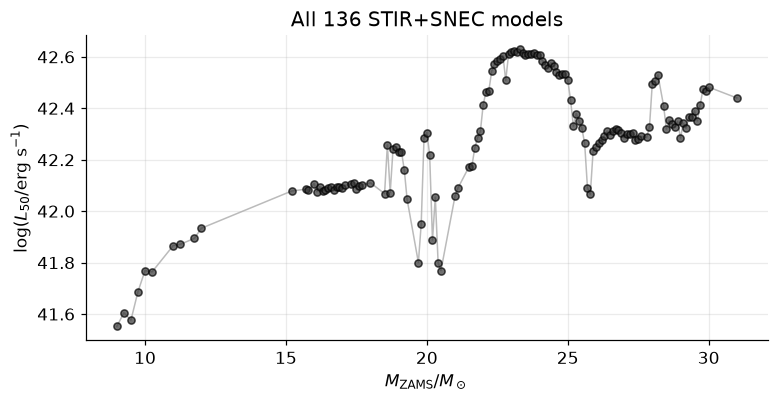

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(pool_X[:, 0], pool_y[:, 0], color='#bbbbbb', lw=1, zorder=1)
ax.scatter(pool_X[:, 0], pool_y[:, 0], color=SEED_C, edgecolor='k', s=22,
           alpha=0.7, zorder=2)
ax.set_xlabel(r'$M_\mathrm{ZAMS} / M_\odot$')
ax.set_ylabel(r'$\log (L_{50} / \mathrm{erg\ s^{-1}})$')
ax.set_title(f'All {len(pool_X)} STIR+SNEC models')
plt.show()

In [7]:
gaps = np.diff(pool_X[:, 0])
wide = np.flatnonzero(gaps > 0.5)
print('sampling is mostly uniform, but the pool has real holes in it:')
for i in wide:
    print(f'  {pool_X[i, 0]:6.2f} -> {pool_X[i + 1, 0]:6.2f} Msun   '
          f'({gaps[i]:.2f} Msun gap)')
print(f'\nmodal spacing elsewhere: {np.median(gaps):.2f} Msun')

sampling is mostly uniform, but the pool has real holes in it:
   10.25 ->  11.00 Msun   (0.75 Msun gap)
   12.00 ->  15.20 Msun   (3.20 Msun gap)
   30.00 ->  31.00 Msun   (1.00 Msun gap)

modal spacing elsewhere: 0.10 Msun


So the pool is not a clean uniform grid. It is dense almost everywhere and empty across a
3.2 $M_\\odot$ stretch between 12 and 15.2 $M_\\odot$ — which is exactly the sort of thing
posterior variance is good at noticing.

The relation itself climbs from 9 $M_\\odot$, and the sharpest structure sits near
18–20 $M_\\odot$, where $\\log L_{50}$ swings by more than 2 dex per $M_\\odot$ before
settling into a noisy plateau. That is the kind of structure where sampling location
matters: the sharp part needs resolution, the plateau largely does not.

## 3. Seeding a coarse design

Start with 12 models spaced as evenly in mass as the pool allows — the campaign you would
plan knowing nothing about the response — and hold the rest back. The GP decides which of
them to 'run'.

Two settings worth noting. `bounds` pins candidate sampling to the full mass range rather
than letting it shrink to whatever the current data happens to span, and `n_eval` fixes the
points at which progress is measured, so the uncertainty curve in section 5 is comparable
from step to step instead of carrying fresh Monte Carlo noise each time.

In [8]:
N_INITIAL = 12
N_STEPS = 28


def uniform_in_mass(n):
    """Indices of n DISTINCT pool models spaced as evenly in mass as possible.

    Two target masses can share a nearest model where the pool is sparse, so
    collisions fall through to the next-closest model rather than collapsing.
    Without that, a nominally n-model control would quietly get fewer than n.
    """
    chosen = []
    for target in np.linspace(X_LO, X_HI, n):
        for candidate in np.argsort(np.abs(pool_X[:, 0] - target)):
            if candidate not in chosen:
                chosen.append(int(candidate))
                break
    return np.array(sorted(chosen))


def pool_at(idx):
    """(X, y) for a set of pool indices."""
    return pool_X[idx], pool_y[idx]


seed_idx = uniform_in_mass(N_INITIAL)
print(f'seed masses: {np.round(pool_X[seed_idx, 0], 2)}')

ast = Astral(test_name='stir-snec', n_test=1500, n_eval=3000,
             bounds=[(X_LO, X_HI)], seed=SEED, runs_dir='runs', verbose=False)
ast.set_data(*pool_at(seed_idx))

#-- Register the pool, marking the seed models as already used
ast.set_pool(pool_X, pool_y)
ast.pool_used[seed_idx] = True

ast.train_gp()
print(f'seeded with {len(ast.X)} models, '
      f'{(~ast.pool_used).sum()} left in the pool')
print(f'fitted kernel: {ast.gp.kernels_[0]}')
print(f'mean band width: {ast.mean_uncertainty():.6f}')

seed masses: [ 9.  11.  12.  15.2 17.  19.  21.  23.  25.  27.  29.  31. ]
seeded with 12 models, 124 left in the pool
fitted kernel: WhiteKernel(noise_level=0.302) + 1.17**2 * RBF(length_scale=1.52)
mean band width: 1.209154


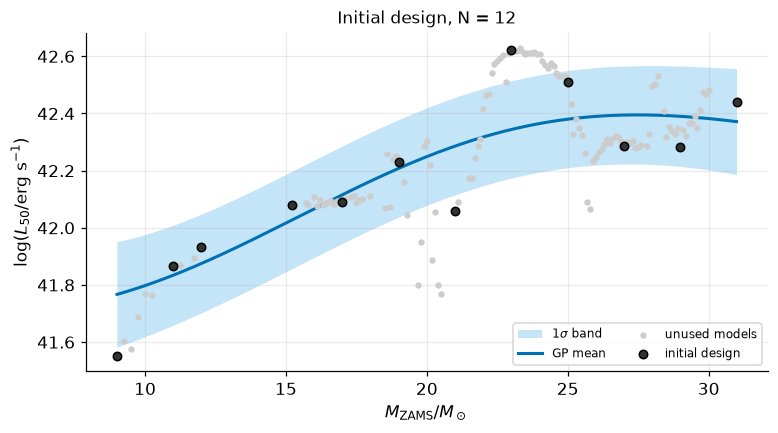

In [9]:
def plot_state(ast, ax, n_initial=N_INITIAL, title=None):
    """Posterior band over the full pool, with training models marked."""
    mean, lower, upper = ast.band_physical()
    x = ast.test_X_physical[:, 0]
    o = np.argsort(x)

    ax.fill_between(x[o], lower[o, 0], upper[o, 0], color=BAND, alpha=0.35,
                    lw=0, label=r'$1\sigma$ band')
    ax.plot(x[o], mean[o, 0], color=MEAN, lw=2, label='GP mean')
    ax.scatter(pool_X[:, 0], pool_y[:, 0], color='#cccccc', s=10, zorder=2,
               label='unused models')
    ax.scatter(ast.X[:n_initial, 0], ast.y[:n_initial, 0], color=SEED_C,
               edgecolor='k', s=30, zorder=3, label='initial design')
    if len(ast.X) > n_initial:
        ax.scatter(ast.X[n_initial:, 0], ast.y[n_initial:, 0], color=ADDED_C,
                   edgecolor='k', s=36, zorder=4, label='placed by GP')
    ax.set_title(title or f'N = {len(ast.X)}', fontsize=11)
    return ax


fig, ax = plt.subplots(figsize=(8, 4))
plot_state(ast, ax, title=f'Initial design, N = {N_INITIAL}')
ax.set_xlabel(r'$M_\mathrm{ZAMS} / M_\odot$')
ax.set_ylabel(r'$\log (L_{50} / \mathrm{erg\ s^{-1}})$')
ax.legend(loc='lower right', fontsize=8, ncol=2)
plt.show()

## 4. Spending the simulation budget

Twenty-eight steps. Each one fits the GP, draws fresh candidates, finds the mass at which
the posterior variance is largest, and reveals the nearest unused model from the pool — the
pool stand-in for dispatching a simulation and waiting for it.

In [10]:
SNAPSHOTS = (12, 20, 30, 40)
frames = {}

for _ in range(N_STEPS):
    ast.train_gp()
    if len(ast.X) in SNAPSHOTS:
        frames[len(ast.X)] = (ast.band_physical(),
                              ast.test_X_physical[:, 0].copy(),
                              ast.X[:, 0].copy(), ast.y[:, 0].copy())
    ast.step()

ast.train_gp()
frames[len(ast.X)] = (ast.band_physical(), ast.test_X_physical[:, 0].copy(),
                      ast.X[:, 0].copy(), ast.y[:, 0].copy())

u = ast.history['uncertainty']
print(f'{N_INITIAL} -> {len(ast.X)} models '
      f'({100 * len(ast.X) / len(pool_X):.0f}% of the full pool)')
print(f'mean band width {u[0]:.5f} -> {ast.mean_uncertainty():.5f} '
      f'({100 * ast.mean_uncertainty() / u[0]:.1f}% of initial)')

12 -> 40 models (29% of the full pool)
mean band width 1.20915 -> 0.31825 (26.3% of initial)


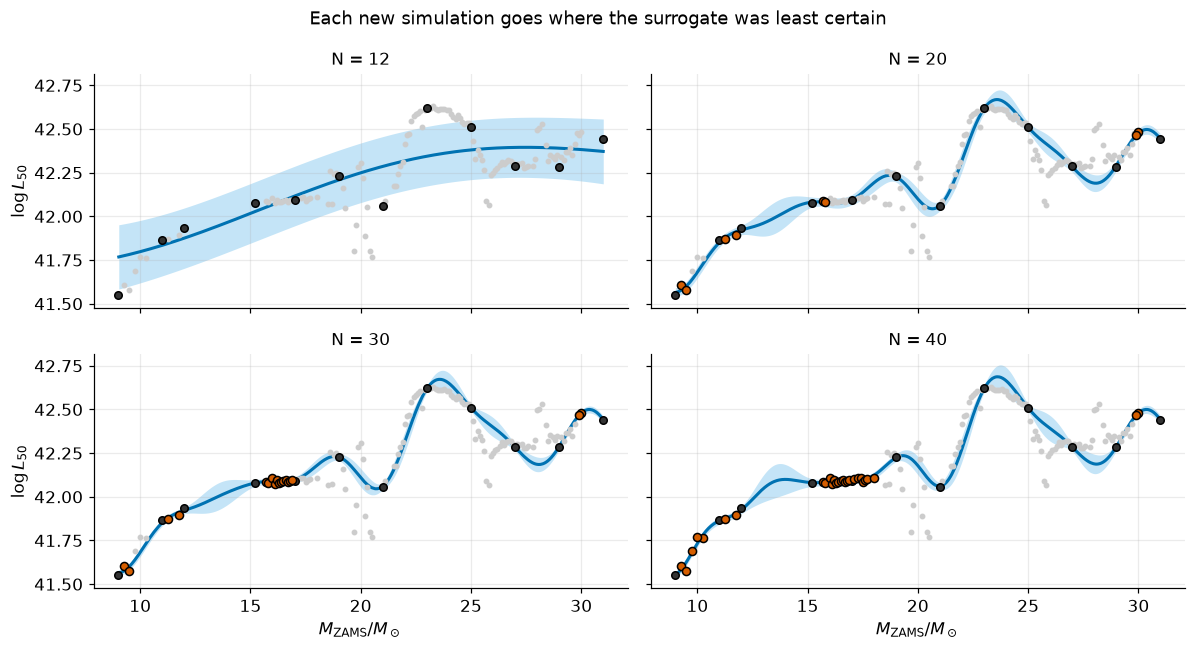

In [11]:
keys = sorted(frames)[:4]
fig, axes = plt.subplots(2, 2, figsize=(11, 6), sharex=True, sharey=True)

for ax, n in zip(axes.ravel(), keys):
    (mean, lower, upper), xt, gx, gy = frames[n]
    o = np.argsort(xt)
    ax.fill_between(xt[o], lower[o, 0], upper[o, 0], color=BAND, alpha=0.35,
                    lw=0)
    ax.plot(xt[o], mean[o, 0], color=MEAN, lw=2)
    ax.scatter(pool_X[:, 0], pool_y[:, 0], color='#cccccc', s=8, zorder=2)
    ax.scatter(gx[:N_INITIAL], gy[:N_INITIAL], color=SEED_C, edgecolor='k',
               s=24, zorder=3)
    ax.scatter(gx[N_INITIAL:], gy[N_INITIAL:], color=ADDED_C, edgecolor='k',
               s=28, zorder=4)
    ax.set_title(f'N = {n}', fontsize=11)

for ax in axes[-1]:
    ax.set_xlabel(r'$M_\mathrm{ZAMS} / M_\odot$')
for ax in axes[:, 0]:
    ax.set_ylabel(r'$\log L_{50}$')

fig.suptitle('Each new simulation goes where the surrogate was least certain',
             fontsize=12)
fig.tight_layout()
plt.show()

## 5. Uncertainty against $N$

This is the original study's headline figure: mean posterior band width as the campaign
grows.

The control needs care. Re-picking an evenly spaced campaign from scratch at every $N$ gives
a *different* point set each time, so the hyperparameter fit restarts in a different basin
and the curve bounces around meaninglessly (section 5.1). The fair comparison is a control
that grows the same way the adaptive campaign does — **nested**, each design a superset of
the last. We use the obvious non-adaptive space-filling rule: always split the widest gap.

In [12]:
def nested_bisection(seed_idx, n_total):
    """Grow a space-filling design by repeatedly splitting the widest mass gap.

    Non-adaptive: it never looks at y, only at where the points are. That makes
    it the right foil for variance-driven placement, which also never looks at
    y but does look at the fitted kernel.
    """
    chosen = list(seed_idx)
    while len(chosen) < n_total:
        held = np.sort(pool_X[chosen, 0])
        midpoints = 0.5 * (held[1:] + held[:-1])
        widest = midpoints[np.argmax(np.diff(held))]
        for candidate in np.argsort(np.abs(pool_X[:, 0] - widest)):
            if candidate not in chosen:
                chosen.append(int(candidate))
                break
    return np.array(sorted(chosen))


def band_width_for(idx):
    """Mean posterior band width for a campaign of the given pool models."""
    control = Astral(test_name='control', n_test=1500, n_eval=3000,
                     bounds=[(X_LO, X_HI)], seed=SEED, runs_dir='runs',
                     verbose=False)
    control.set_data(*pool_at(idx))
    control.train_gp()
    return control.mean_uncertainty()


n_grid = np.array(ast.history['n'])
u_astral = np.array(ast.history['uncertainty'])
u_nested = np.array([band_width_for(nested_bisection(seed_idx, int(n)))
                     for n in n_grid])

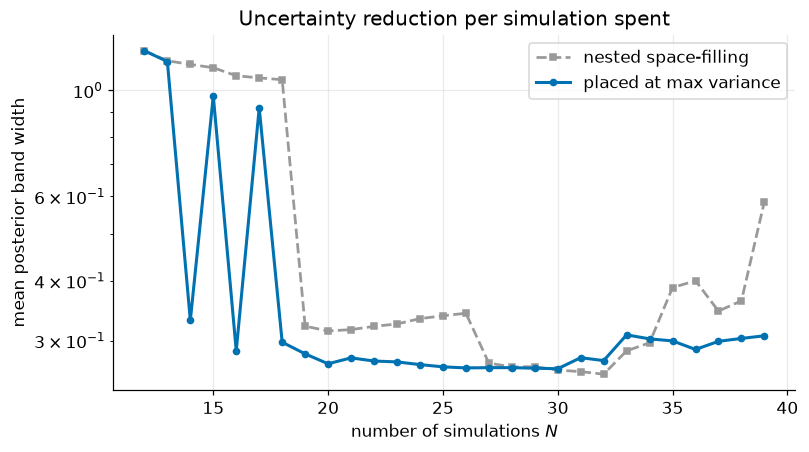

start  N = 12:  1.2092
end    N = 39:  variance-driven 0.3069   space-filling 0.5855

variance-driven reaches 25% of the initial band width, 1.9x lower than space-filling at equal cost


In [13]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(n_grid, u_nested, color='#999999', lw=1.8, ls='--', marker='s',
        ms=3.5, label='nested space-filling')
ax.plot(n_grid, u_astral, color=MEAN, lw=2, marker='o', ms=4,
        label='placed at max variance')
ax.set_xlabel('number of simulations $N$')
ax.set_ylabel('mean posterior band width')
ax.set_yscale('log')
ax.legend()
ax.set_title('Uncertainty reduction per simulation spent')
plt.show()

print(f'start  N = {n_grid[0]}:  {u_astral[0]:.4f}')
print(f'end    N = {n_grid[-1]}:  variance-driven {u_astral[-1]:.4f}   '
      f'space-filling {u_nested[-1]:.4f}')
print(f'\nvariance-driven reaches '
      f'{100 * u_astral[-1] / u_astral[0]:.0f}% of the initial band width, '
      f'{u_nested[-1] / u_astral[-1]:.1f}x lower than space-filling at equal cost')

Variance-driven placement wins **at the thing it optimises**, by roughly a factor of two at
equal cost. The blue curve is the noisier of the two: its design changes adaptively, so the
refit hyperparameters move around more than they do under a control that grows smoothly.

### 5.1 Why the control has to be nested

Worth seeing once, because it will bite anyone who builds a comparison casually. If instead
you re-pick an evenly spaced campaign from scratch at every $N$, you get this:

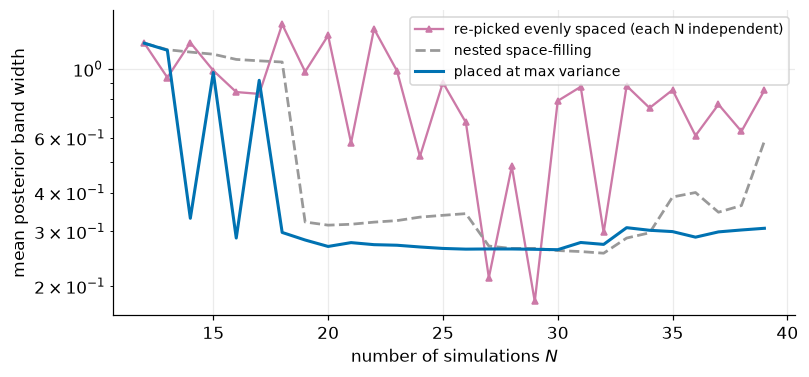

mean step-to-step change in the curve:
  variance-driven       25.3%
  nested space-filling   9.3%
  re-picked             58.8%   <- not a usable baseline

re-picked spans 0.178 - 1.391, a factor of 8


In [14]:
u_repicked = np.array([band_width_for(uniform_in_mass(int(n)))
                       for n in n_grid])

wobble = lambda v: 100 * np.mean(np.abs(np.diff(v)) / v[:-1])

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(n_grid, u_repicked, color='#CC79A7', lw=1.5, marker='^', ms=4,
        label='re-picked evenly spaced (each N independent)')
ax.plot(n_grid, u_nested, color='#999999', lw=1.8, ls='--',
        label='nested space-filling')
ax.plot(n_grid, u_astral, color=MEAN, lw=2, label='placed at max variance')
ax.set_xlabel('number of simulations $N$')
ax.set_ylabel('mean posterior band width')
ax.set_yscale('log')
ax.legend(fontsize=9)
plt.show()

print('mean step-to-step change in the curve:')
print(f'  variance-driven      {wobble(u_astral):5.1f}%')
print(f'  nested space-filling {wobble(u_nested):5.1f}%')
print(f'  re-picked            {wobble(u_repicked):5.1f}%   '
      f'<- not a usable baseline')
print(f'\nre-picked spans {u_repicked.min():.3f} - {u_repicked.max():.3f}, '
      f'a factor of {u_repicked.max() / u_repicked.min():.0f}')

Adding a single model changes the point set enough that the hyperparameter fit lands in a
different mode of the marginal likelihood. Nothing about the underlying problem changed by a
factor of eight; only the optimiser's basin did.

This is the same root cause as the degenerate fit in section 8 of notebook 1. Nested designs
keep the fit in one basin and the curve interpretable.

## 6. Where did the simulations go?

One distinction first. `history['placement']` is the mass the GP **asked** for;
`history['added']` is the model the pool actually **delivered**. With a live simulator the
two are identical — you run whatever mass you like. A pool can only serve the nearest run
it still has.

In [15]:
requested = np.array(ast.history['placement'])[:, 0]
delivered = np.array(ast.history['added'])[:, 0]

print(f"{'step':>5} {'requested':>11} {'delivered':>11}")
for i in range(8):
    print(f'{i:>5} {requested[i]:>11.2f} {delivered[i]:>11.2f}')

 step   requested   delivered
    0       31.00       30.00
    1        9.01        9.25
    2       13.71       11.75
    3       30.99       29.90
    4       13.80       15.70
    5        9.01        9.50
    6       13.64       15.80
    7       13.59       11.25


Two patterns show up in that table. Some requests are for the **domain edges** at 9 and
31 $M_\\odot$, where the GP has data on one side only; the pool has no model at 31 to give
back a second time, so it serves 30.0, then 29.9, walking inward while the GP keeps asking
for the edge. The rest cluster near **13.7** $M_\\odot$ — the middle of the 3.2 $M_\\odot$
hole — and the pool answers from whichever side it can, 11.75 or 15.70.

Both are the rule working correctly, and both illustrate the same caveat: **a pool is not a
simulator.** Where the pool is empty exactly where the variance is highest, the requested and
delivered points diverge, and some of the budget is spent approximating a location you cannot
actually sample.

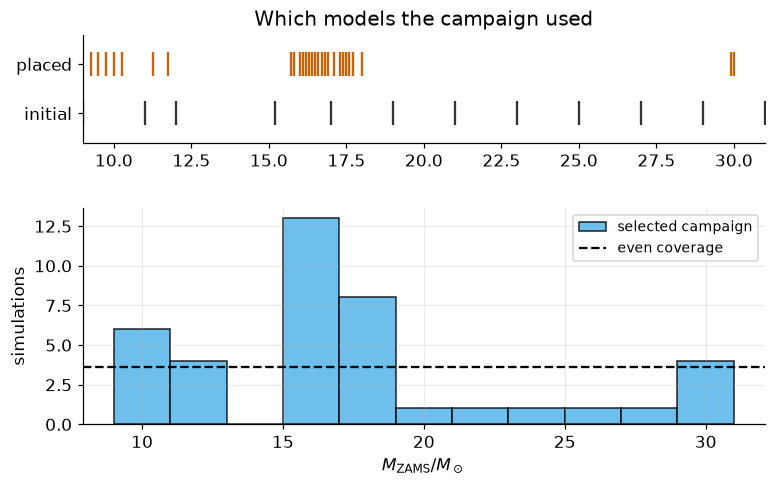

campaign spans 9.25 - 30.00 Msun


In [16]:
added = ast.X[N_INITIAL:, 0]

fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 4.6),
                               gridspec_kw={'height_ratios': [1, 2],
                                            'hspace': 0.4})

ax0.scatter(ast.X[:N_INITIAL, 0], np.zeros(N_INITIAL), marker='|', s=240,
            color=SEED_C)
ax0.scatter(added, np.ones(len(added)), marker='|', s=240, color=ADDED_C)
ax0.set_yticks([0, 1]); ax0.set_yticklabels(['initial', 'placed'])
ax0.set_ylim(-0.6, 1.6); ax0.set_xlim(X_LO, X_HI); ax0.grid(False)
ax0.set_title('Which models the campaign used')

ax1.hist(ast.X[:, 0], bins=11, range=(X_LO, X_HI), color=BAND, edgecolor='k',
         alpha=0.85, label='selected campaign')
ax1.axhline(len(ast.X) / 11, color='k', ls='--', lw=1.5, label='even coverage')
ax1.set_xlabel(r'$M_\mathrm{ZAMS} / M_\odot$')
ax1.set_ylabel('simulations')
ax1.legend(fontsize=9)
plt.show()

print(f'campaign spans {added.min():.2f} - {added.max():.2f} Msun')

## 7. How well does the surrogate predict?

Section 5 shows the method minimising posterior variance, which is its stated objective. But
variance is the model's opinion of its own ignorance, and the scientific question is
different: **how well does the surrogate predict the simulations it never ran?**

Those are not the same question, so we check directly — against the nested space-filling
control, an evenly spaced campaign, and an ensemble of random ones at the same budget.

In [17]:
def held_out_rms(idx):
    """RMS error on every pool model not in idx."""
    model = Astral(test_name='score', n_test=800, seed=SEED, runs_dir='runs',
                   verbose=False)
    model.set_data(*pool_at(idx))
    model.train_gp()

    predicted, _, _ = model.gp.predict_physical(
        (pool_X - model.x_mean) / model.x_std)
    held = np.setdiff1d(np.arange(len(pool_X)), idx)
    return float(np.sqrt(np.mean((predicted[held, 0] - pool_y[held, 0]) ** 2)))


astral_idx = np.array([int(np.abs(pool_X[:, 0] - x).argmin())
                       for x in ast.X[:, 0]])
N = len(astral_idx)

rng = np.random.default_rng(0)
rms_random = np.array([
    held_out_rms(np.sort(rng.choice(len(pool_X), N, replace=False)))
    for _ in range(40)])

print(f'N = {N} models ({100 * N / len(pool_X):.0f}% of the pool), '
      f'{len(pool_X) - N} held out\n')
print(f"{'campaign':>26} {'held-out RMS (dex)':>20}")
print(f"{'variance-driven':>26} {held_out_rms(astral_idx):>20.5f}")
print(f"{'nested space-filling':>26} "
      f'{held_out_rms(nested_bisection(seed_idx, N)):>20.5f}')
print(f"{'evenly spaced':>26} {held_out_rms(uniform_in_mass(N)):>20.5f}")
print(f"{'random, mean of 40':>26} {rms_random.mean():>20.5f}")
print(f"{'random, 10-90 pct':>26} "
      f'{np.percentile(rms_random, 10):.5f} - '
      f'{np.percentile(rms_random, 90):.5f}')
print(f'\nfor scale, the relation itself has std {pool_y.std():.5f} dex')

N = 40 models (29% of the pool), 96 held out

                  campaign   held-out RMS (dex)
           variance-driven              0.13252
      nested space-filling              0.12024
             evenly spaced              0.08849
        random, mean of 40              0.11114
         random, 10-90 pct 0.08381 - 0.15094

for scale, the relation itself has std 0.24560 dex


**On held-out error the variance-driven campaign does not win.** It is close to the
space-filling control and worse than an evenly spaced or typical random campaign.

That is a real result, not a bug, and it is worth understanding rather than hiding:

- **In one dimension with a stationary kernel, even spacing is already near-optimal.**
  Posterior variance depends only on distance to the nearest data, so spreading points evenly
  is close to the best available design. There is very little room to beat it.
- **Maximum variance is not maximum information about the response.** Variance is highest
  where data is *absent* — the domain edges, the pool's holes — which need not be where the
  function is doing anything interesting. Notebook 1 section 7 makes the same point on a 2-D
  target whose structure the campaign cheerfully ignores.
- **This relation is noisy.** The fitted white-noise term is a large fraction of the signal,
  so much of the structure near 18–20 $M_\\odot$ is scatter, and no placement strategy can
  predict scatter.

The method earns its keep elsewhere: in higher dimensions, where filling the space uniformly
is not an option at all; when the response has structure concentrated somewhere you cannot
identify in advance; and when a campaign may be stopped at an arbitrary point, since every
prefix of an adaptive campaign is a sensible design while a prefix of a uniform sweep is not.

In [18]:
cov = np.ravel(ast.coverage(alphas=(0.68, 0.95, 0.99)))

print('coverage of the final surrogate (nominal -> empirical):')
for alpha, c in zip((0.68, 0.95, 0.99), cov):
    print(f'  {alpha:.2f} -> {c:.3f}')

print('\nOver-coverage means the error bars are conservative: the surrogate is')
print('less certain than it needs to be. Since those error bars drove every')
print('placement decision, this is the diagnostic to watch.')

coverage of the final surrogate (nominal -> empirical):
  0.68 -> 0.900
  0.95 -> 0.975
  0.99 -> 0.975

Over-coverage means the error bars are conservative: the surrogate is
less certain than it needs to be. Since those error bars drove every
placement decision, this is the diagnostic to watch.


## Summary

Starting from 12 evenly spaced models and adding 28 chosen by posterior variance, this
notebook reproduces the placement loop the original controller ran against live MESA jobs —
in seconds rather than weeks, because the simulations already exist.

What it shows:

- The loop **does what it claims**. Mean posterior band width falls to about a quarter of its
  initial value, roughly twice as low as a non-adaptive space-filling campaign of equal cost.
- **Placement ignores $y$ entirely.** Posterior variance depends only on where the training
  points sit, so a campaign can in principle be planned before any simulation returns.
- **A pool is not a simulator.** Where the pool is sparse and the variance high, requested and
  delivered masses diverge and the budget drains toward the domain edges.
- **Compare nested designs only.** Re-picking a control from scratch at each $N$ makes the
  uncertainty curve swing by a factor of eight for reasons that have nothing to do with the
  design and everything to do with which mode the optimiser landed in.
- **Lower variance is not automatically better prediction.** On held-out models this campaign
  does not beat even spacing. In 1-D, on a noisy, densely sampled relation, that is the
  honest expected outcome.

Notebook 3 fits all three light-curve outputs at once and shows what changes when you tell
the campaign which of them you care about.